In [33]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import math

from uqct.datasets.utils import get_dataset, KWARGS_LAMINO, KWARGS_LUNG, KWARGS_COMPOSITE
from uqct.metrics import get_metrics


from uqct.ct import forward_and_fbp_2d, _circular_mask

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
trainSet, testSet_lamino = get_dataset(KWARGS_LAMINO, 'tiff')
trainSet, testSet_composite = get_dataset(KWARGS_COMPOSITE, 'nii')
trainSet, testSet_lung = get_dataset(KWARGS_LUNG, 'h5')

In [35]:
images = torch.stack([
    testSet_lamino[0],
    testSet_composite[0],
    testSet_lung[0],
]).to(device).squeeze(1)
images.shape
images.min(), images.max()

(tensor(0., device='cuda:0'), tensor(0.6498, device='cuda:0'))

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.22628390789031982,[0.0, 0.4783537983894348]
Image: mean: 0.22760766744613647,[0.0, 0.5084212422370911]
Circle • Dense (180)  PSNR:  31.38 dB   SSIM: 0.9547


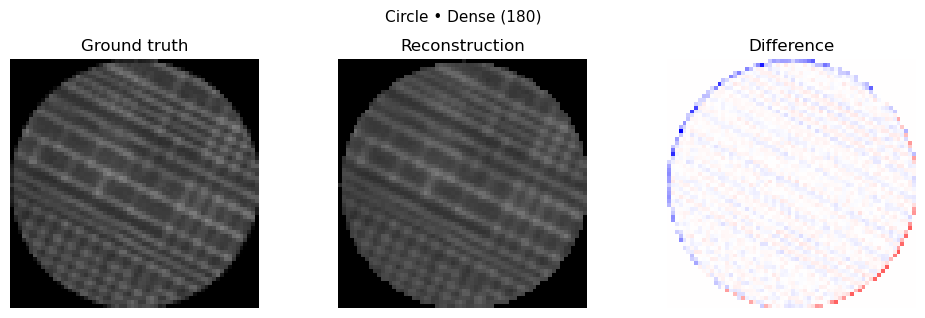

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.22632916271686554,[0.0, 0.47561588883399963]
Image: mean: 0.22760766744613647,[0.0, 0.5084212422370911]
Circle • Medium (60)  PSNR:  27.92 dB   SSIM: 0.8141


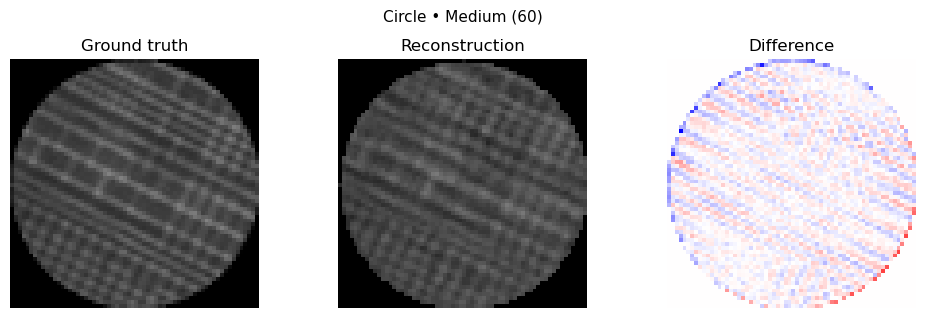

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.2270873785018921,[0.0, 0.6173868775367737]
Image: mean: 0.22760766744613647,[0.0, 0.5084212422370911]
Circle • Sparse (12)  PSNR:  20.86 dB   SSIM: 0.4559


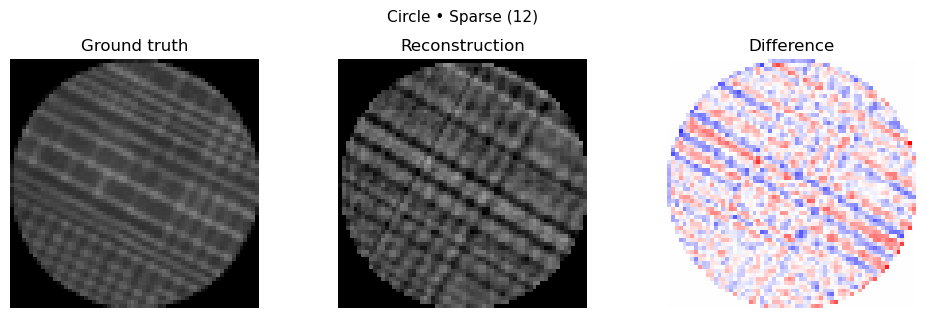

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.3082164525985718,[0.0, 0.6392802000045776]
Image: mean: 0.3089207410812378,[0.0, 0.6261999011039734]
Square • Dense (180)  PSNR:  28.64 dB   SSIM: 0.9569


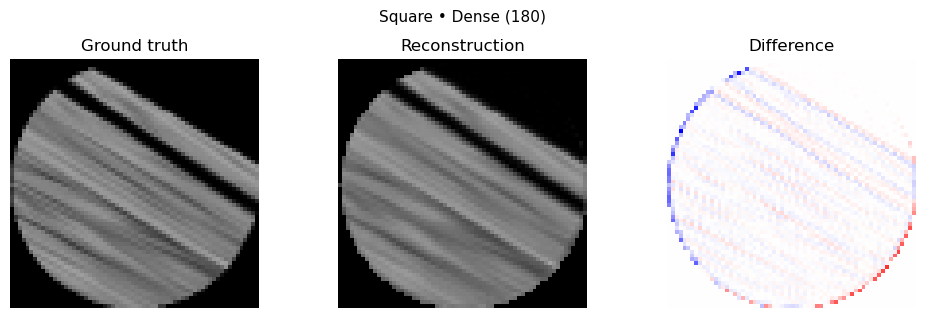

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.3090853691101074,[0.0, 0.7409819960594177]
Image: mean: 0.3089207410812378,[0.0, 0.6261999011039734]
Square • Medium (60)  PSNR:  26.60 dB   SSIM: 0.9033


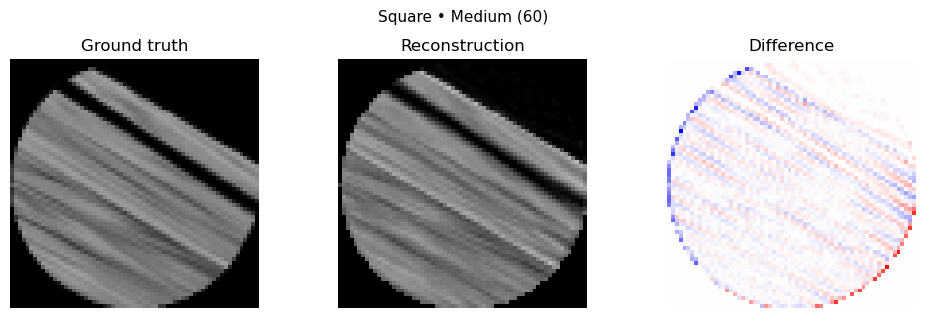

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.3433987498283386,[0.0, 1.0]
Image: mean: 0.3089207410812378,[0.0, 0.6261999011039734]
Square • Sparse (12)  PSNR:  14.30 dB   SSIM: 0.5041


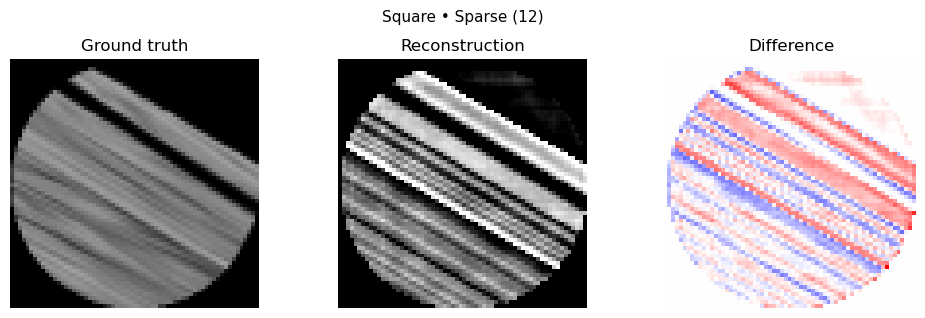

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.11625629663467407,[0.0, 0.36484599113464355]
Image: mean: 0.1169065535068512,[0.0, 0.4196335971355438]
Stripes • Dense (180)  PSNR:  36.57 dB   SSIM: 0.9742


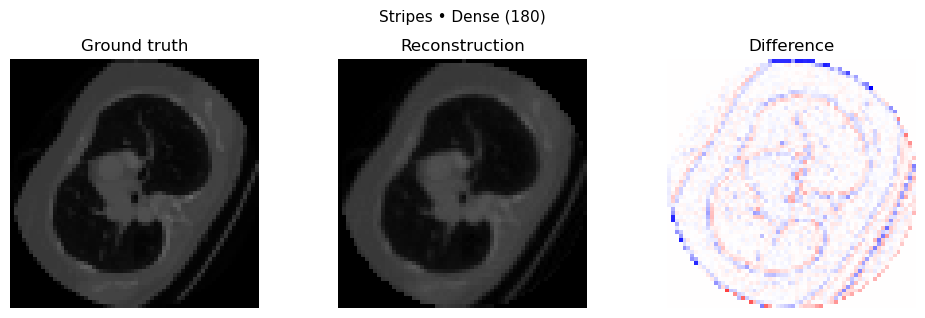

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.11662818491458893,[0.0, 0.36028674244880676]
Image: mean: 0.1169065535068512,[0.0, 0.4196335971355438]
Stripes • Medium (60)  PSNR:  34.15 dB   SSIM: 0.9421


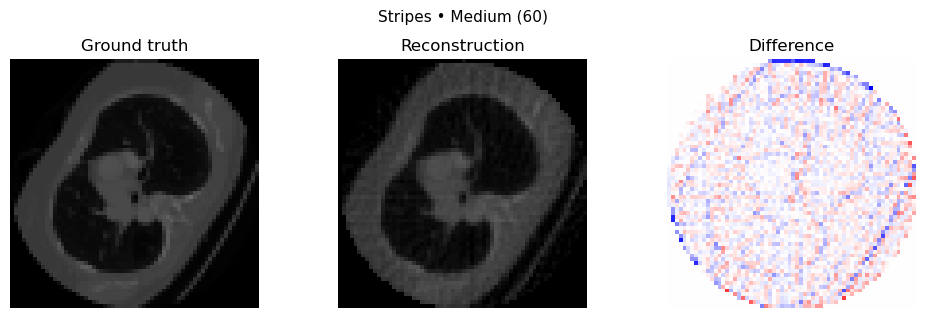

torch.Size([64, 64]) torch.Size([128, 128])
Recon: mean: 0.1283119171857834,[0.0, 0.681385338306427]
Image: mean: 0.1169065535068512,[0.0, 0.4196335971355438]
Stripes • Sparse (12)  PSNR:  21.75 dB   SSIM: 0.5633


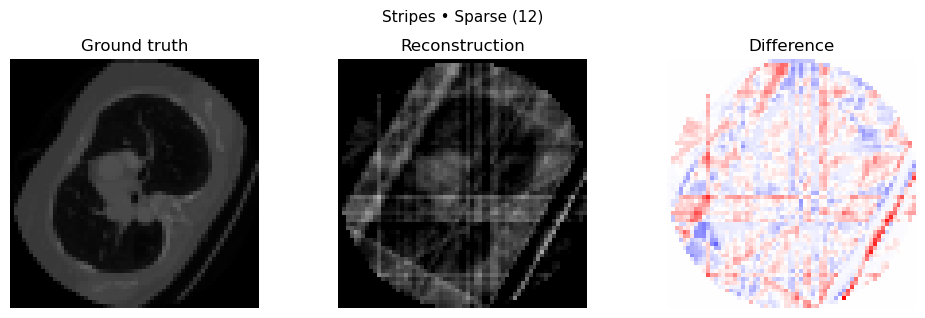

In [37]:
def show_gt_recon_diff(gt: torch.Tensor, recon: torch.Tensor, title: str = ""):
    """
    gt, recon: [H,W] on any device. Values assumed roughly in [0,1].
    """
    gt_ = gt.detach().cpu().float().numpy()
    rc_ = recon.detach().cpu().float().numpy()
    diff = rc_ - gt_

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    axes[0].imshow(gt_, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Ground truth")
    axes[0].axis("off")

    axes[1].imshow(rc_, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Reconstruction")
    axes[1].axis("off")

    # symmetric range for difference
    m = np.max(np.abs(diff)) + 1e-6
    axes[2].imshow(diff, cmap="bwr", vmin=-m, vmax=m)
    axes[2].set_title("Difference")
    axes[2].axis("off")

    if title:
        fig.suptitle(title, y=0.98, fontsize=11)
    plt.tight_layout()
    plt.show()


def demo_checkable_fbps(
    im_size: int = 256,
    device: str = "cuda",
    filter_name: str = "ramp",
    circle: bool = True,
):
    """
    Builds 3 simple images, uses 3 angle sets of different densities,
    runs FP->FBP via fbps_for_angle_sets_2d, and plots/prints metrics.
    """
    dev = torch.device(device if torch.cuda.is_available() else "cpu")

    
    # Three easily-checkable angle sets:
    angle_sets = [
        np.linspace(0, 360, 180, endpoint=False)[:-1],  # 180
        np.linspace(0, 360, 60, endpoint=False)[:-1],  # 60
        np.linspace(0, 360, 12, endpoint=False)[:-1],  # 12
    ]

    # We’ll run one reconstruction per (image, angle_set) pair
    all_recons: list[torch.Tensor] = []
    all_titles: list[str] = []

    labels = ["Circle", "Square", "Stripes"]
    dens = ["Dense (180)", "Medium (60)", "Sparse (12)"]

    for i in range(len(images)):
        # same image, three different angle sets
        recons, I_0s = forward_and_fbp_2d(
            images[i],
            angle_sets,
            len(images) * [1e8],
            filter_name=filter_name,
            circle=circle,
        )
        for j, r in enumerate(recons):
            # clip to [0,1] for visualization
            r = torch.clamp(r, 0.0, 1.0)
            all_recons.append(r)
            all_titles.append(f"{labels[i]} • {dens[j]}")

    # Plot & metrics
    k = 0
    for i in range(len(images)):
        for j in range(len(angle_sets)):
            recon = all_recons[k]
            print(recon.shape, images[i].shape)

            # resize ground truth to recon resolution
            gt = images[i].unsqueeze(0).unsqueeze(0)
            image = (
                F.interpolate(gt, size=recon.shape[-2:], mode="area")
                .squeeze(0)
                .squeeze(0)
            )
            print(f"Recon: mean: {recon.mean()},[{recon.min()}, {recon.max()}]")
            print(f"Image: mean: {image.mean()},[{image.min()}, {image.max()}]")

            title = all_titles[k]
            p = psnr(image, recon, data_range=1.0)
            s = ssim(image, recon, data_range=1.0)
            print(f"{title:20s}  PSNR: {p:6.2f} dB   SSIM: {s:0.4f}")
            show_gt_recon_diff(image, recon, title=title)
            k += 1


demo_checkable_fbps(im_size=256, device="cuda", filter_name="ramp", circle=True)